# Exploratory Data Analysis (EDA) of METAR Observations

## What is Exploratory Data Analysis?

Exploratory Data Analysis is the process of investigating a dataset to uncover patterns, identify anomalies, test hypotheses, and understand the data's characteristics before proceeding with formal statistical analysis or visualization. In meteorology, EDA is crucial for understanding observational datasets from stations like the Lancaster Airport (LNS).

This notebook walks through a systematic approach to EDA using ASOS (Automated Surface Observing System) data from the LNS station. We'll examine:
- Data quality and missing values
- Distributions of various meteorological variables
- Relationships between variables
- Temporal patterns in the observations

**Key Principle**: Throughout this analysis, we emphasize **robust and resistant** statistical methods. These methods are less sensitive to outliers and data anomalies, providing more reliable insights into your data.

In [2]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the METAR Data

We'll load data from the Lincoln, Nebraska (LNS) ASOS station. This automated station records observations including temperature, dew point, wind speed/direction, pressure, and sky cover conditions. The first step is to read the CSV file and create a datetime index for time-series analysis.

In [62]:
asos_data = pd.read_csv('data/LNS.csv', parse_dates=['valid'])
asos_data.set_index('valid', inplace=True)

### Step 1: Handling Duplicate Records

Raw observational data often contains duplicate entries due to data transmission issues or quality control procedures. Removing duplicates ensures we're working with unique observations and prevents biasing our statistical analyses. This is a fundamental data cleaning step that should always be performed early in your EDA workflow.

In [63]:
asos_data = asos_data.reset_index().drop_duplicates(subset='valid').set_index('valid')

### Step 2: Handling Missing Data

Observational datasets frequently contain missing values due to instrument failures, data transmission issues, or calibration periods. Rather than discarding data, we can use **interpolation** to estimate missing values, especially for continuous variables like temperature.

The time-based interpolation method fills gaps by assuming linear changes between valid observations—a reasonable assumption for many meteorological variables over short time intervals. Visualizing original vs. interpolated data helps us assess the quality of our estimation.

<Axes: xlabel='valid', ylabel='Temperature [F]'>

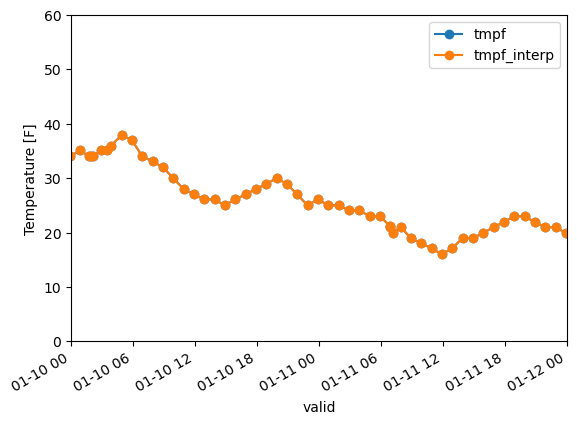

In [64]:
asos_data['tmpf_interp'] = asos_data['tmpf'].interpolate(method='time')
asos_data.plot(kind='line', y=['tmpf','tmpf_interp'],\
               ylabel='Temperature [F]',\
               xlim=('2022-01-10','2022-01-12'),\
               ylim=(0,60), marker='o')


## Categorical Data in Pandas

Some METAR columns contain categorical data (text values) rather than numerical measurements. Examples include:
- **wxcodes**: Present weather (e.g., "RA" for rain, "SN" for snow)
- **skyc1-skyc4**: Sky cover descriptions at different cloud layers (e.g., "FEW", "SCT", "BKN", "OVC")

Converting these to categorical type in Pandas improves memory efficiency and enables specialized analysis techniques for categorical variables. This is a best practice that prepares your data for proper statistical treatment.

In [65]:
asos_data['wxcodes'] = asos_data['wxcodes'].astype('category')
asos_data['skyc1'] = asos_data['skyc1'].astype('category')
asos_data['skyc2'] = asos_data['skyc2'].astype('category')
asos_data['skyc3'] = asos_data['skyc3'].astype('category')
asos_data['skyc4'] = asos_data['skyc4'].astype('category')

#### Visualizing Categorical Frequencies

Bar charts showing value counts are an effective way to understand the distribution of categorical variables. Here we're looking at the most frequent weather codes and sky cover conditions in our dataset. The `iloc[:20]` for weather codes limits the display to the top 20 categories for clarity—categorical variables often have many unique values, and visualizing the most common ones reveals patterns in atmospheric conditions.

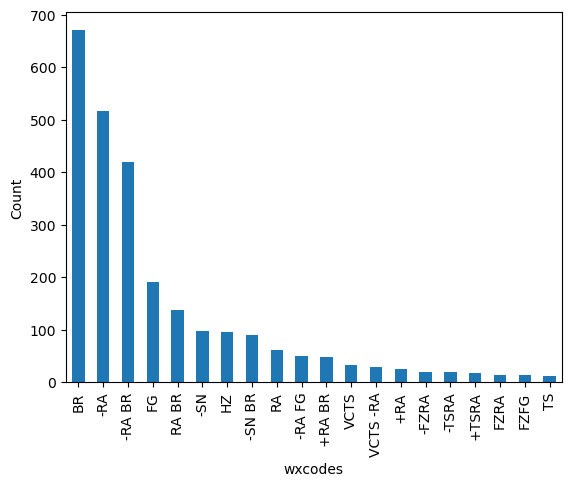

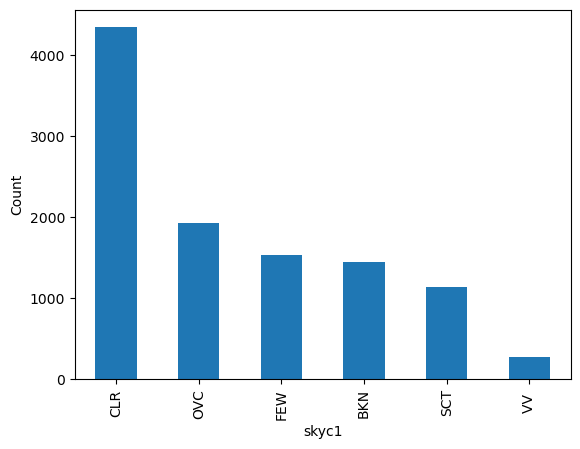

In [66]:
asos_data['wxcodes'].value_counts().iloc[:20].plot(kind='bar', ylabel='Count')
plt.show()
asos_data['skyc1'].value_counts().plot(kind='bar', ylabel='Count')
plt.show()

## Identifying Outliers with Z-Scores

The Z-score is a standardized measure that indicates how many standard deviations a value is from the mean. Z-scores help identify potential outliers:
- Values between -2 and +2 are considered "normal" (within ~95% of data)
- Values beyond ±3 are statistical outliers (beyond ~99.7% of data)

Visualizing Z-scores across time helps detect anomalies in the observational record. This is valuable for quality control, as unusual values might indicate instrument malfunctions or data transmission errors. However, remember that Z-scores assume your data is normally distributed—a limitation worth considering when working with meteorological data that may have skewed distributions.

<Axes: xlabel='valid', ylabel='Z-Score'>

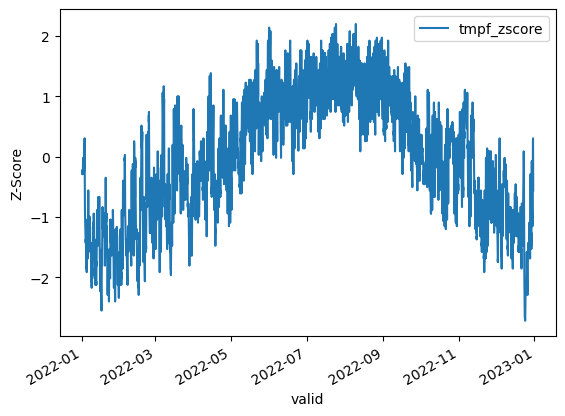

In [67]:
from scipy.stats import zscore

asos_data['tmpf_zscore'] = zscore(asos_data['tmpf'], nan_policy='omit')
asos_data.plot(kind='line', y='tmpf_zscore', ylabel='Z-Score')

## Understanding Relationships Between Variables: Scatter Plots

Scatter plots reveal relationships (correlations) between pairs of variables. In meteorology, we expect relationships between variables due to physical processes. For example:
- Temperature (tmpf) and pressure (mslp) often show relationships due to air mass characteristics
- Temperature and wind speed can relate to atmospheric instability

We can enhance scatter plots by encoding a third variable using color. In the first plot, we color points by dew point (dwpf), showing how moisture varies with temperature and pressure relationships.

In this second scatter plot, temperature is compared against wind speed, with colors representing the hour of day (0-23). This reveals diurnal (daily) cycles in wind speed—a strong pattern in many locations where land surface heating drives afternoon wind increases.

<Axes: xlabel='tmpf', ylabel='mslp'>

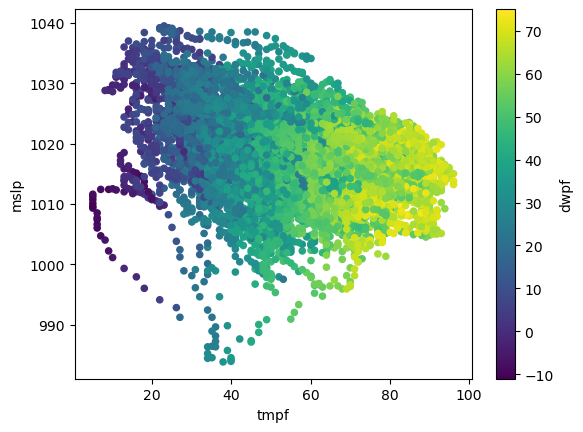

In [68]:
asos_data.plot(kind='scatter', x='tmpf', y='mslp', c='dwpf')

<Axes: xlabel='Temperature [F]', ylabel='Wind Speed [knots]'>

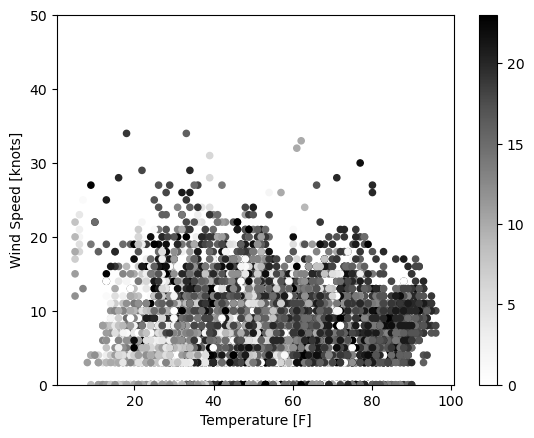

In [69]:
asos_data.plot(kind='scatter',x='tmpf',y='sknt',c=asos_data.index.hour, colorbar=True, ylim=(0,50), xlabel='Temperature [F]', ylabel='Wind Speed [knots]')

## Correlation Analysis: Three Approaches

Correlation measures the strength and direction of linear relationships between variables. However, different correlation methods have different strengths:

### Pearson Correlation
The classic Pearson correlation coefficient assumes:
- Linear relationships
- Normally distributed data
- No outliers (it's sensitive to extreme values)

Pearson is the most common method but can be misleading when these assumptions are violated. A heatmap provides an overview of all correlations in the dataset simultaneously.

<Axes: >

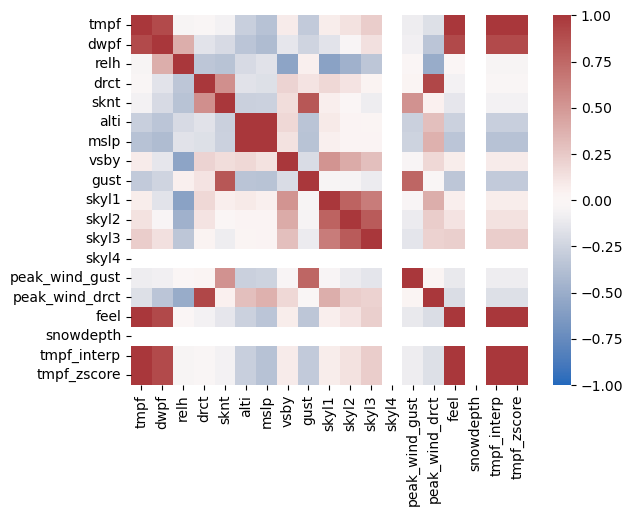

In [70]:
# We want to compute the correlation for only data types that are numbers.
pearson = asos_data.select_dtypes(include=[np.number]).corr(method='pearson')

sns.heatmap(pearson, cmap="vlag", vmin=-1, vmax=1)

### Robust Correlation Methods: Spearman and Kendall's Tau

In contrast to Pearson, Spearman's rank correlation and Kendall's Tau are **robust** correlation methods:

- **Spearman Rank Correlation**: Measures monotonic relationships (not necessarily linear). It ranks data values and computes correlations on ranks, making it resistant to outliers. This is more appropriate for meteorological data that often has skewed distributions.

- **Kendall's Tau**: Another rank-based measure that's even more resistant to outliers than Spearman. It directly counts concordant and discordant pairs, providing a different perspective on relationships.

**Why use robust methods?** Real meteorological data often contains outliers from instrument errors, extreme events, or unusual atmospheric conditions. Robust methods tell you about the typical relationship while ignoring extreme values—a more realistic picture of how variables usually behave together.

In [71]:
spearman = asos_data.select_dtypes(include=[np.number]).corr(method='spearman')
kendall = asos_data.select_dtypes(include=[np.number]).corr(method='kendall')

<Axes: >

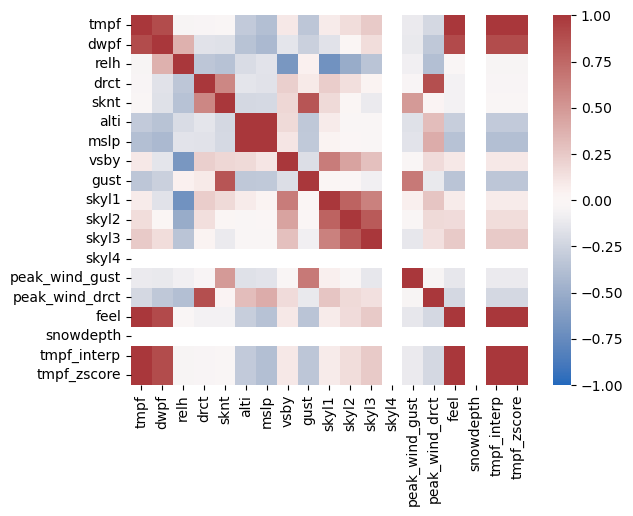

In [72]:
sns.heatmap(spearman, cmap="vlag", vmin=-1, vmax=1)

## Temporal Patterns: Serial Correlation and Autocorrelation

Sequential observations taken over time are not independent—they're *serially correlated*. This is especially true for meteorological variables, which change gradually rather than randomly jumping between values. This temporal structure is important to understand because it violates assumptions of many statistical tests.

The **Autocorrelation Function (ACF)** measures how strongly each observation is correlated with previous observations at different time lags. For example:
- ACF at lag 1 shows correlation between consecutive time steps
- ACF at lag 24 shows daily cycles (observations 24 hours apart)
- A high ACF indicates the variable is slow to change
- A low ACF indicates the variable fluctuates rapidly

The horizontal lines show confidence bands (95% and 99%). Values outside these bands indicate significant serial correlation.

To examine autocorrelation, we'll:
1. Interpolate missing temperature values to create a complete time series
2. Resample to regular hourly intervals (ASOS observations vary in frequency)
3. Focus on a specific month to identify clear patterns

In [73]:
# Creating Autocorrelation plot
asos_data['tmpf_interp'] = asos_data['tmpf'].interpolate(method='time')
temp_ts = asos_data['tmpf_interp'].loc['2022-01-10 00:00':'2022-01-31 00:00']
temp_ts = temp_ts.drop_duplicates()
# drop duplicate timestamps (fixes "cannot reindex on an axis with duplicate labels")

temp_ts2 = temp_ts.resample('H').nearest()

/var/folders/51/b9llyv5s4dd7llx0xjt1rzkw0000gr/T/ipykernel_70222/149337031.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  temp_ts2 = temp_ts.resample('H').nearest()


### Understanding the Autocorrelation Plot

The dashed line represents the 99% confidence band, and the solid line is the 95% confidence band. Values outside these bands indicate statistically significant autocorrelation. 

Notice how temperature shows high autocorrelation at small lags—consecutive hours have very similar temperatures. Autocorrelation decreases at larger lags (unless there's a periodic pattern like a 24-hour cycle). Understanding these patterns is crucial when:
- Choosing appropriate statistical tests
- Assessing data independence assumptions
- Designing forecasting models
- Understanding physical processes driving the observations

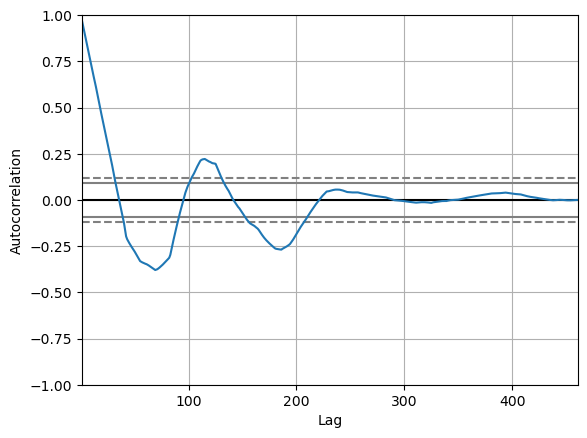

In [74]:
x = pd.plotting.autocorrelation_plot(series=temp_ts2)

# plotting the Curve
x.plot()
 
# Display
plt.show()

## Comprehensive Relationships: Scatter Plot Matrix (Pairplot)

A scatter plot matrix (or "pairplot") shows all pairwise relationships in your dataset simultaneously. This is one of the most powerful EDA tools because:

1. **Diagonal shows distributions**: Each variable's marginal distribution
2. **Off-diagonal scatter plots**: Reveal bivariate relationships
3. **Color coding by category**: We'll color points by sky cover conditions to see if atmospheric conditions create distinct patterns
4. **Pattern recognition**: Clusters, gaps, or unusual structures become visible

This is more robust than looking at individual scatter plots because you can identify which relationships are consistent across the full dataset and which are driven by particular subsets of conditions.

In [75]:
subset = asos_data.loc[:,['tmpf','dwpf','mslp','gust','sknt','drct','skyc1']]
subset2 = subset.drop_duplicates()

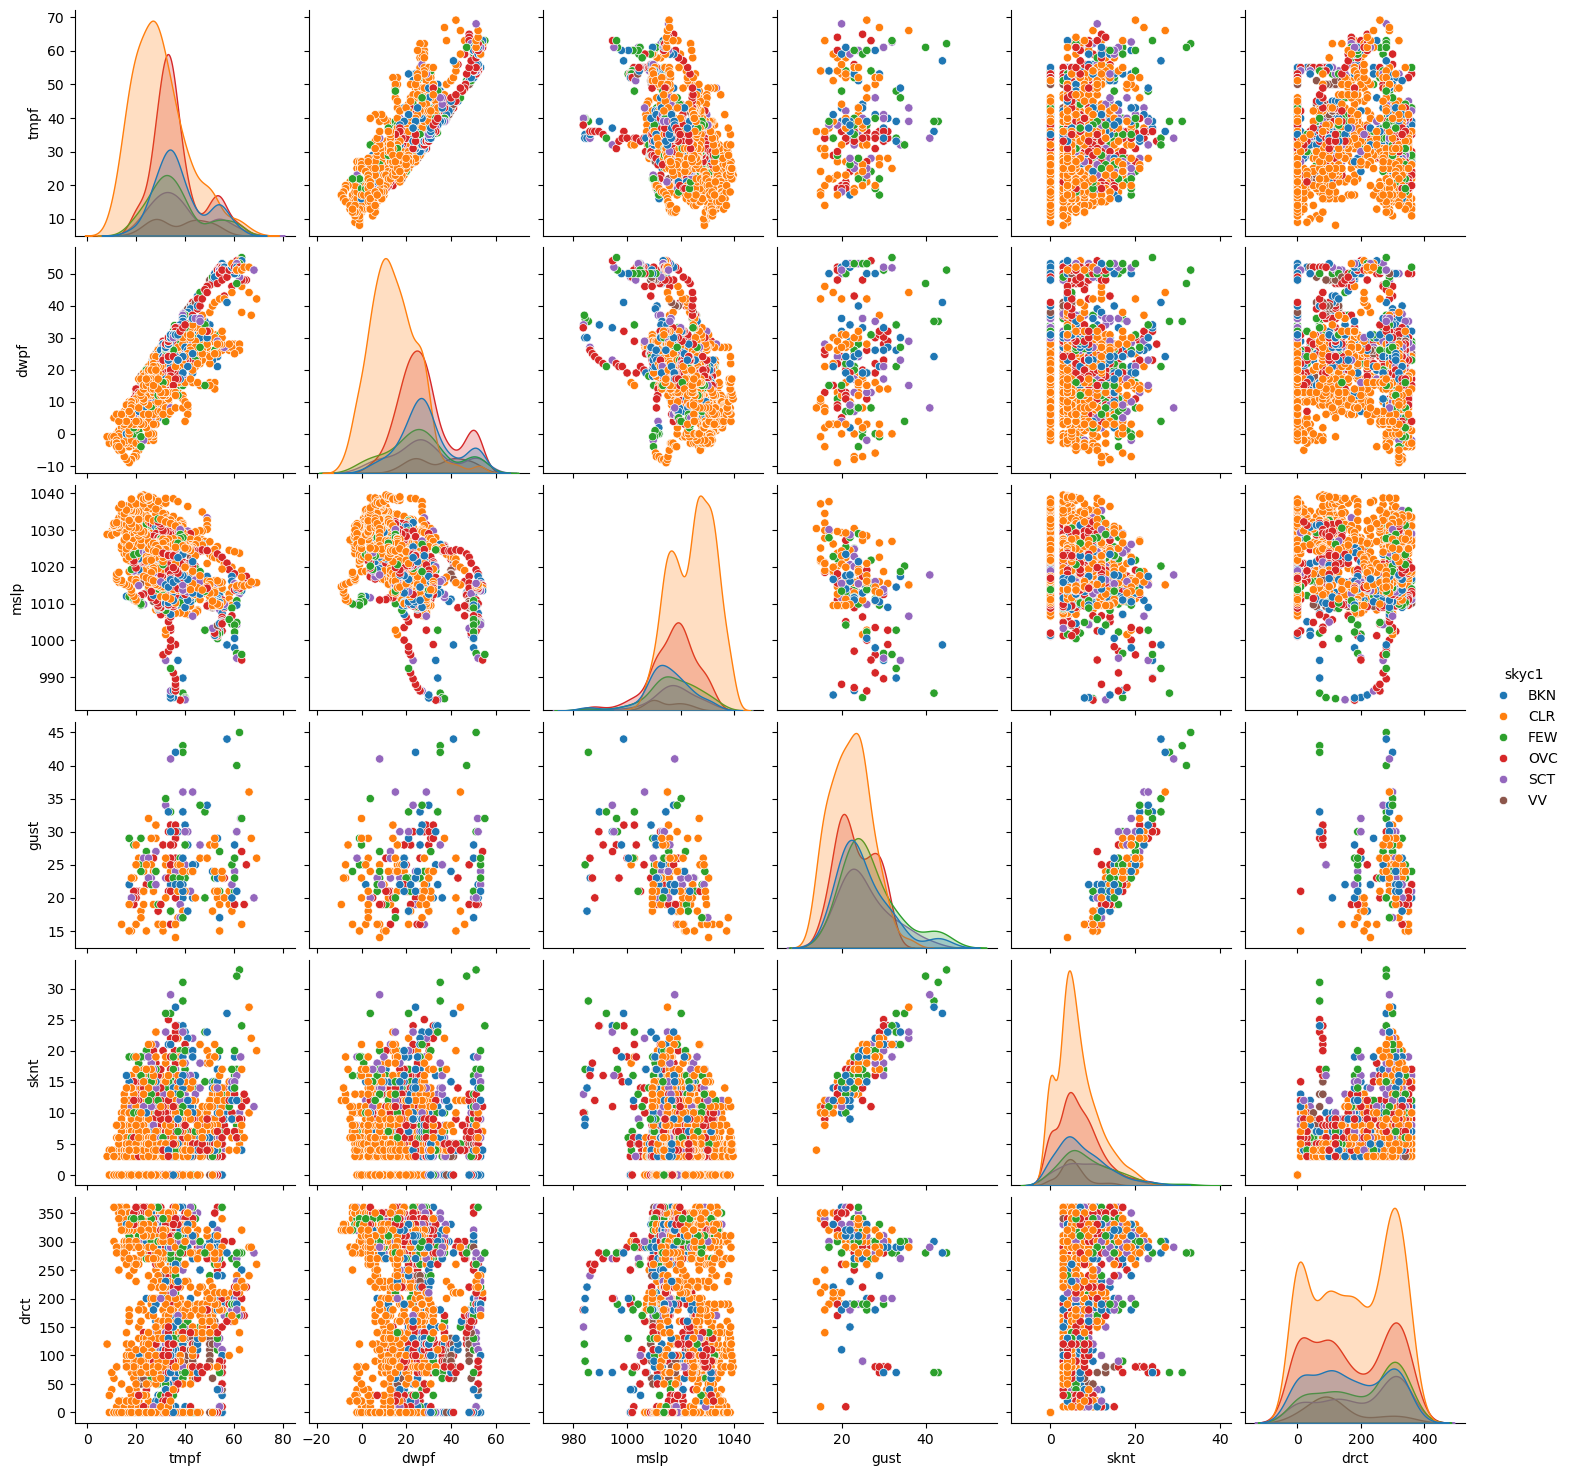

In [76]:
sns.pairplot(subset2.loc['2022-01-01':'2022-03-01'], hue='skyc1', dropna=True)

## Additional Seaborn Visualization Techniques

Seaborn provides powerful statistical visualization tools that are excellent for EDA. These plots automatically compute and display robust statistics, making them ideal for exploratory work.

### Distribution Analysis with Violin Plots

Violin plots show the full distribution of a continuous variable across categories. Unlike box plots which only show quartiles, violin plots display the complete distribution shape, making them more informative for understanding your data.

/var/folders/51/b9llyv5s4dd7llx0xjt1rzkw0000gr/T/ipykernel_70222/3841895334.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=subset2, x='skyc1', y='tmpf', palette='Set2')
/var/folders/51/b9llyv5s4dd7llx0xjt1rzkw0000gr/T/ipykernel_70222/3841895334.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset2, x='skyc1', y='sknt', palette='Set2')


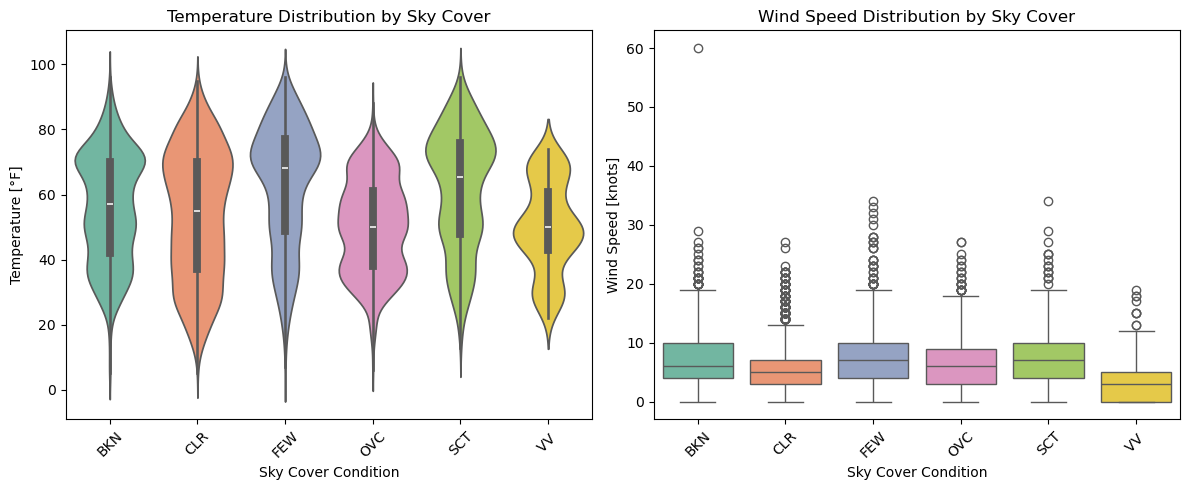

In [77]:
plt.figure(figsize=(12, 5))

# Violin plot for temperature by sky cover condition
plt.subplot(1, 2, 1)
sns.violinplot(data=subset2, x='skyc1', y='tmpf', palette='Set2')
plt.title('Temperature Distribution by Sky Cover')
plt.ylabel('Temperature [°F]')
plt.xlabel('Sky Cover Condition')
plt.xticks(rotation=45)

# Box plot for wind speed by sky cover (more compact distribution view)
plt.subplot(1, 2, 2)
sns.boxplot(data=subset2, x='skyc1', y='sknt', palette='Set2')
plt.title('Wind Speed Distribution by Sky Cover')
plt.ylabel('Wind Speed [knots]')
plt.xlabel('Sky Cover Condition')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Why violin and box plots?** These are **robust visualizations** because they display the underlying distribution rather than assuming normality. Box plots show quartiles (resistant to outliers), while violin plots reveal the full distribution shape. Together they provide a complete picture of how a variable behaves across categories.

### Joint Plots: Bivariate Analysis with Marginal Distributions

Joint plots display the relationship between two variables plus their individual distributions. This comprehensive view reveals both the correlation and the shape of each variable's distribution.

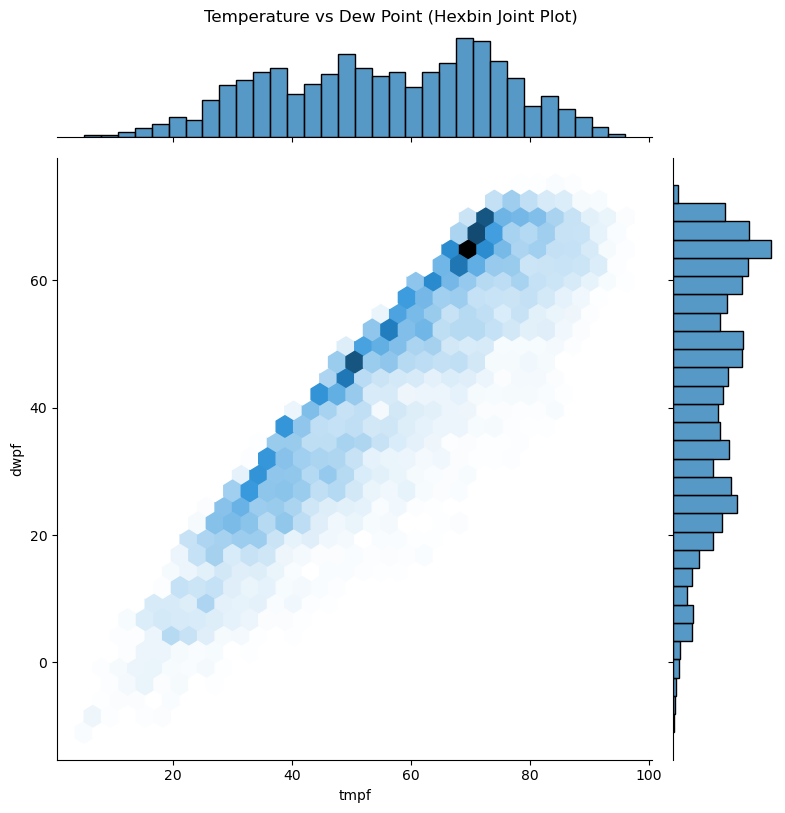

In [78]:
sns.jointplot(data=subset2, x='tmpf', y='dwpf', kind='hex', height=8)
plt.suptitle('Temperature vs Dew Point (Hexbin Joint Plot)', y=1.01)
plt.show()

The hexbin plot is particularly useful because it handles overplotting—when many points overlap, making patterns unclear. By binning points into hexagons and coloring by count, we can see density patterns that would be invisible in a standard scatter plot. This is a **robust visualization** approach that emphasizes data patterns over individual points.

We can also use kernel density estimation (KDE) for a smooth density view:



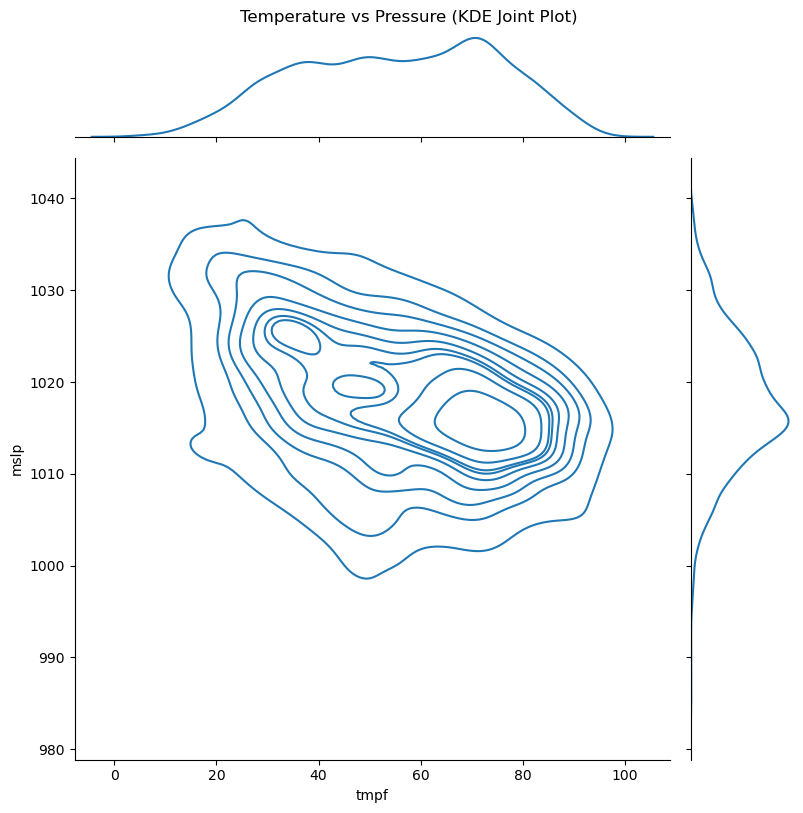

In [79]:
sns.jointplot(data=subset2.dropna(subset=['tmpf', 'mslp']), x='tmpf', y='mslp', kind='kde', height=8)
plt.suptitle('Temperature vs Pressure (KDE Joint Plot)', y=1.01)
plt.show()

### Regression Plots: Visualizing Linear Relationships

Seaborn's `regplot` adds a fitted regression line with confidence bands, providing a visual assessment of the linear relationship and its uncertainty.

/Users/greg.blumberg/miniforge3/envs/default/lib/python3.11/site-packages/numpy/linalg/linalg.py:2030: RuntimeWarning: divide by zero encountered in matmul
  res = matmul(transpose(vt), multiply(s[..., newaxis], transpose(u)))
/Users/greg.blumberg/miniforge3/envs/default/lib/python3.11/site-packages/numpy/linalg/linalg.py:2030: RuntimeWarning: overflow encountered in matmul
  res = matmul(transpose(vt), multiply(s[..., newaxis], transpose(u)))
/Users/greg.blumberg/miniforge3/envs/default/lib/python3.11/site-packages/numpy/linalg/linalg.py:2030: RuntimeWarning: invalid value encountered in matmul
  res = matmul(transpose(vt), multiply(s[..., newaxis], transpose(u)))
/Users/greg.blumberg/miniforge3/envs/default/lib/python3.11/site-packages/numpy/linalg/linalg.py:2030: RuntimeWarning: divide by zero encountered in matmul
  res = matmul(transpose(vt), multiply(s[..., newaxis], transpose(u)))
/Users/greg.blumberg/miniforge3/envs/default/lib/python3.11/site-packages/numpy/linalg/linalg.py:20

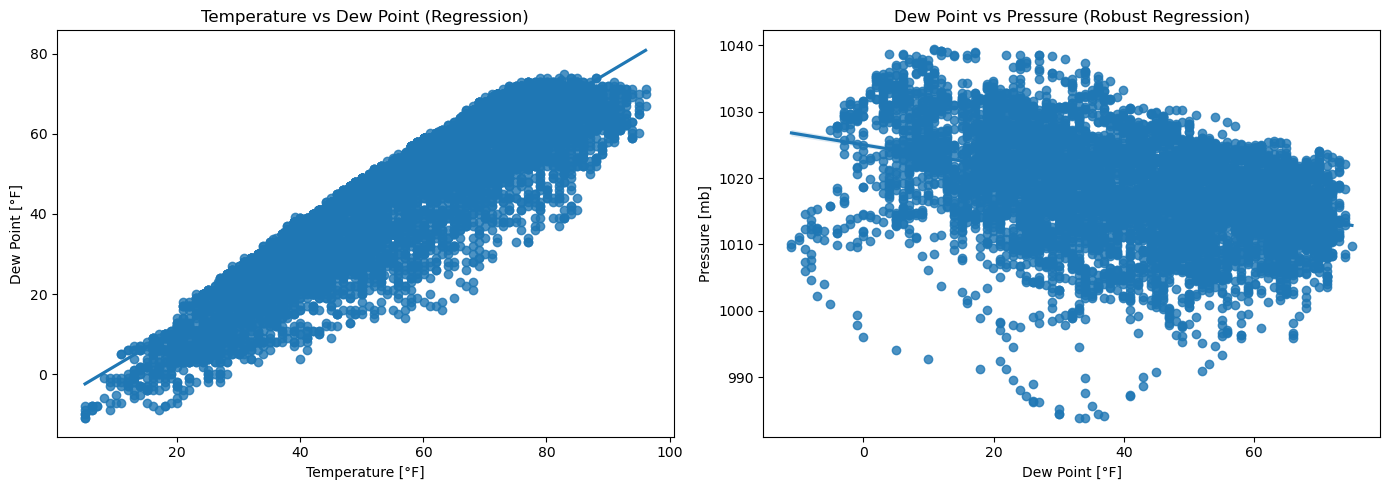

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regression plot with scatter
sns.regplot(data=subset2.dropna(subset=['tmpf', 'dwpf']), x='tmpf', y='dwpf', ax=axes[0])
axes[0].set_title('Temperature vs Dew Point (Regression)')
axes[0].set_ylabel('Dew Point [°F]')
axes[0].set_xlabel('Temperature [°F]')

# Regression plot with robust regression (less sensitive to outliers)
sns.regplot(data=subset2.dropna(subset=['dwpf', 'mslp']), x='dwpf', y='mslp', ax=axes[1], robust=True)
axes[1].set_title('Dew Point vs Pressure (Robust Regression)')
axes[1].set_ylabel('Pressure [mb]')
axes[1].set_xlabel('Dew Point [°F]')

plt.tight_layout()
plt.show()

Notice the `robust=True` parameter in the second plot. Standard regression (left) uses ordinary least squares, which is sensitive to outliers. Robust regression (right) uses RANSAC (Random Sample Consensus), which downweights outliers. For meteorological data with occasional sensor errors or extreme events, robust regression provides a more stable estimate of typical relationships.

### Categorical Relationships: Violin + Swarm Plots

Combining violin plots with swarm plots shows both the distribution shape AND the individual data points, providing a complete picture of categorical relationships.

/var/folders/51/b9llyv5s4dd7llx0xjt1rzkw0000gr/T/ipykernel_70222/772847756.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=subset2.dropna(subset=['tmpf', 'skyc1']), x='skyc1', y='tmpf', palette='muted')
/Users/greg.blumberg/miniforge3/envs/default/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 53.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/greg.blumberg/miniforge3/envs/default/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 81.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/greg.blumberg/miniforge3/envs/default/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 50.8% of

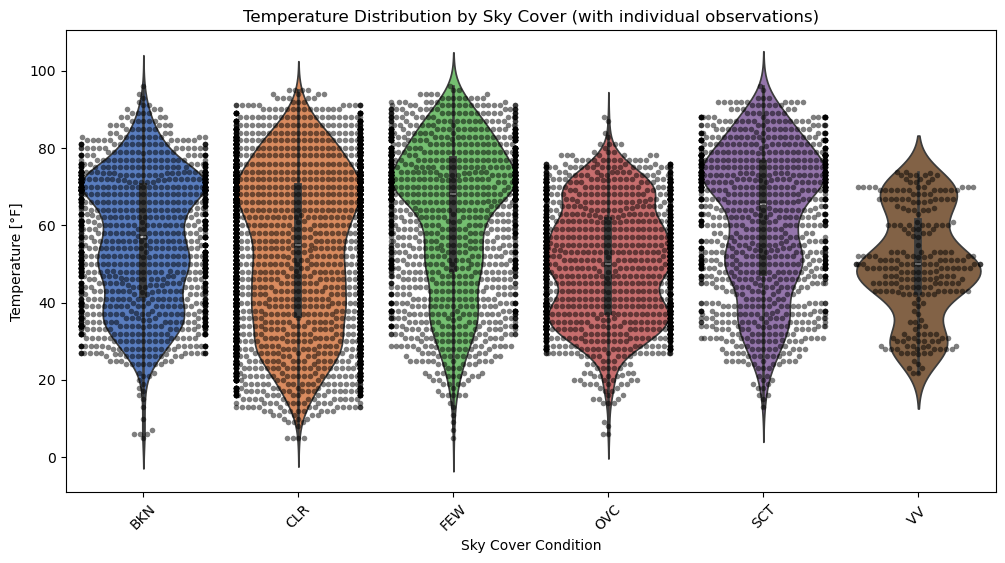

In [81]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=subset2.dropna(subset=['tmpf', 'skyc1']), x='skyc1', y='tmpf', palette='muted')
sns.swarmplot(data=subset2.dropna(subset=['tmpf', 'skyc1']), x='skyc1', y='tmpf', color='black', alpha=0.5, size=4)
plt.title('Temperature Distribution by Sky Cover (with individual observations)')
plt.ylabel('Temperature [°F]')
plt.xlabel('Sky Cover Condition')
plt.xticks(rotation=45)
plt.show()

### Distribution Plots with Histograms and KDE

Seaborn's `histplot` with KDE overlay provides a clear view of variable distributions with both empirical (histogram) and smooth (KDE) representations.

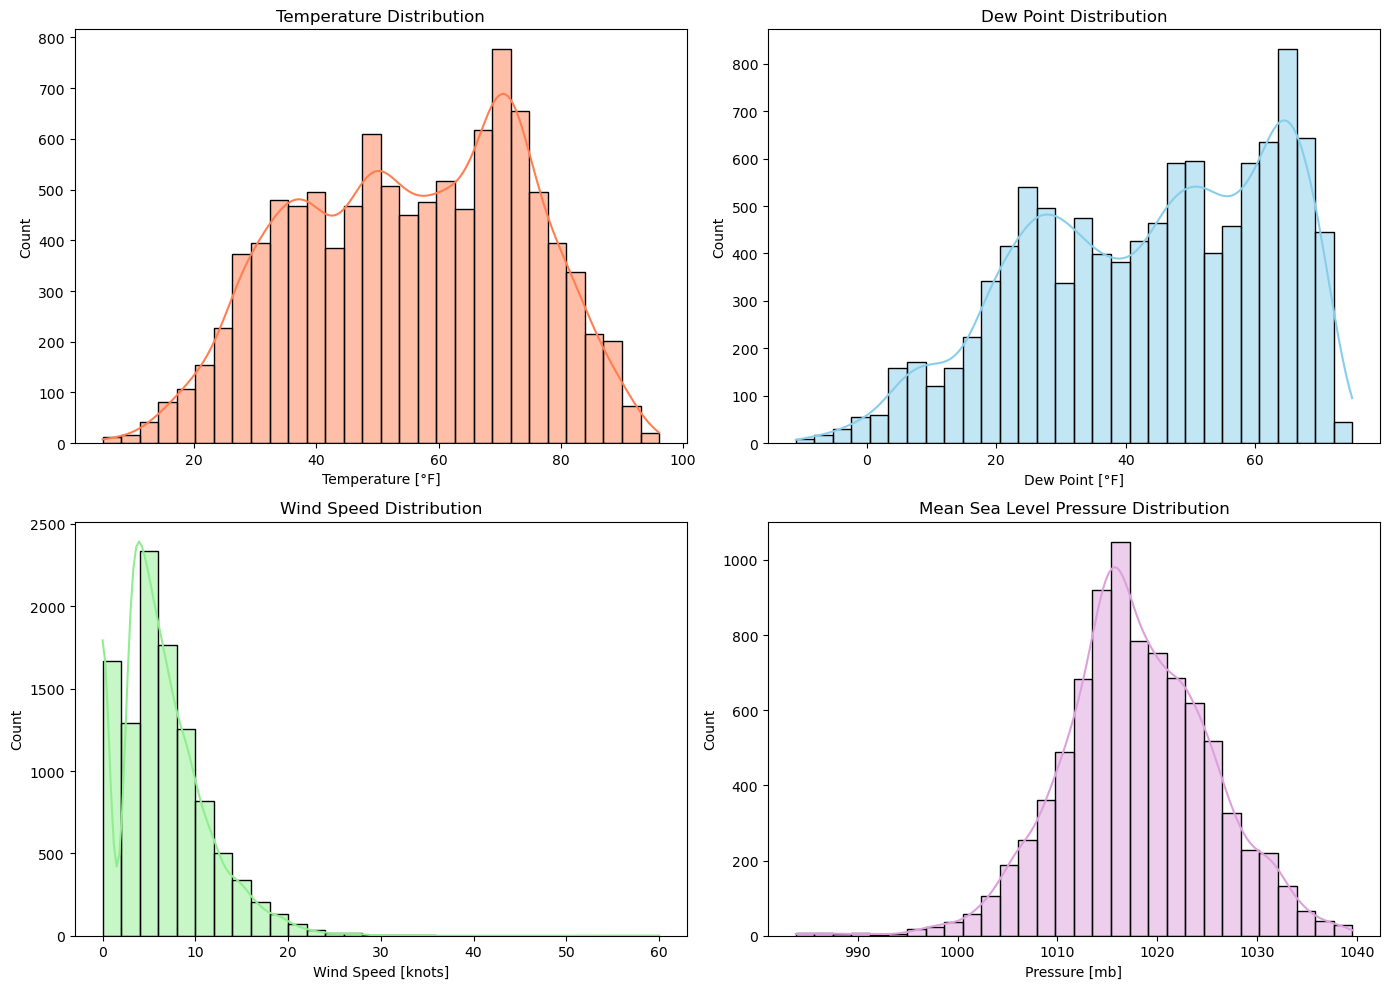

In [82]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Temperature distribution
sns.histplot(data=subset2, x='tmpf', kde=True, bins=30, ax=axes[0, 0], color='coral')
axes[0, 0].set_title('Temperature Distribution')
axes[0, 0].set_xlabel('Temperature [°F]')

# Dew point distribution
sns.histplot(data=subset2, x='dwpf', kde=True, bins=30, ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Dew Point Distribution')
axes[0, 1].set_xlabel('Dew Point [°F]')

# Wind speed distribution (often skewed)
sns.histplot(data=subset2, x='sknt', kde=True, bins=30, ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Wind Speed Distribution')
axes[1, 0].set_xlabel('Wind Speed [knots]')

# Pressure distribution
sns.histplot(data=subset2, x='mslp', kde=True, bins=30, ax=axes[1, 1], color='plum')
axes[1, 1].set_title('Mean Sea Level Pressure Distribution')
axes[1, 1].set_xlabel('Pressure [mb]')

plt.tight_layout()
plt.show()

**What to look for:** These histograms reveal the shape of your distributions. Notice that:
- Temperature and dew point appear relatively normal (symmetric)
- Wind speed is likely right-skewed (longer tail on the right)
- Pressure appears normal with a narrow range

The KDE overlay smooths out the histogram bins and reveals the true underlying distribution shape. This is important because many statistical tests assume normality, and this visualization immediately shows if that assumption holds.

### Clustermap: Hierarchical Clustering of Correlations

The clustermap reorders rows and columns of a correlation matrix based on hierarchical clustering, grouping similar variables together.

<Figure size 1000x800 with 0 Axes>

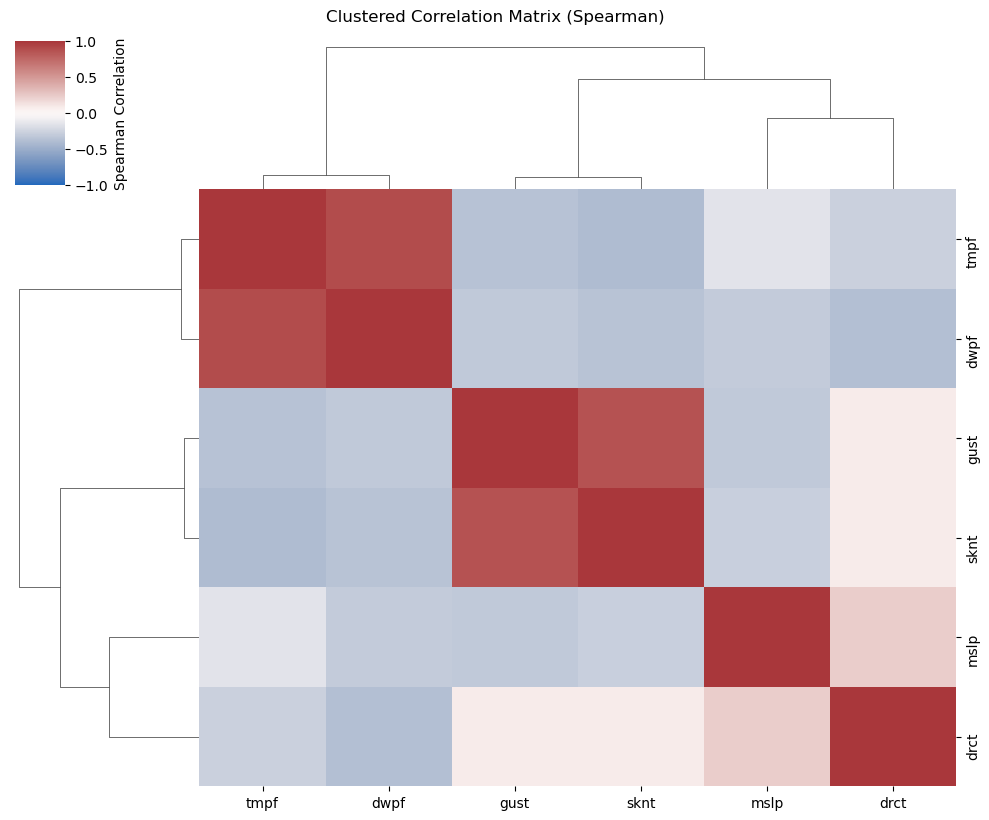

In [83]:
# Select numeric columns for correlation
numeric_subset = subset2[['tmpf', 'dwpf', 'mslp', 'gust', 'sknt', 'drct']].dropna()

# Compute correlation using robust method (Spearman)
corr_matrix = numeric_subset.corr(method='spearman')

# Create clustermap
plt.figure(figsize=(10, 8))
sns.clustermap(corr_matrix, cmap='vlag', vmin=-1, vmax=1, center=0, 
               cbar_kws={'label': 'Spearman Correlation'}, figsize=(10, 8))
plt.suptitle('Clustered Correlation Matrix (Spearman)', y=1.02)
plt.show()

The clustermap automatically identifies groups of variables that are strongly correlated with each other. This helps you understand the underlying structure of your data—which variables contain redundant information and which represent independent physical processes. Notice how this uses Spearman correlation (robust and rank-based) rather than Pearson—a better choice for real meteorological data.

## Summary: Choosing the Right Seaborn Visualization

| Visualization | Best For | Robustness Feature |
|---|---|---|
| **Violin/Box Plot** | Comparing distributions across categories | Displays full distribution, not just summary stats |
| **Joint Plot (Hexbin)** | Bivariate relationships with overplotting | Bins data to show density patterns |
| **Joint Plot (KDE)** | Smooth bivariate density estimation | Robust density estimation |
| **Regplot** | Linear relationships with uncertainty bands | Can use robust regression (RANSAC) |
| **Swarm + Violin** | Categorical comparisons with individual points | Shows both distribution and data points |
| **Histplot with KDE** | Single variable distributions | KDE smooths histogram noise |
| **Clustermap** | Correlation structure with grouping | Hierarchical clustering reveals patterns |

Each of these techniques emphasizes robust visualization principles: showing data uncertainty, handling outliers gracefully, and revealing patterns without assuming normality or making other restrictive assumptions about your data.

## Key Takeaways from This EDA

By systematically working through this notebook, you've learned:

1. **Data Quality Matters**: Cleaning duplicates and handling missing values is foundational
2. **Multiple Visualization Approaches**: Different plot types reveal different patterns
3. **Robust Methods are Important**: Spearman and Kendall correlations tell a more accurate story than Pearson when outliers are present
4. **Temporal Structure Exists**: Real data isn't random—observations are correlated through time
5. **Relationships Are Multifaceted**: Pairplots reveal patterns that individual scatter plots might miss
6. **Context is Essential**: Coloring plots by categories (like sky cover) shows how atmospheric conditions cluster together

**For your own EDA**, follow this systematic approach:
- Start with data cleaning and quality checks
- Visualize single variables (distributions)
- Explore relationships between pairs of variables
- Look for temporal patterns if working with time series
- Use categorical grouping to reveal conditional patterns
- Always question what you see—is the pattern real or an artifact of the data?

This methodical approach ensures you understand your data before jumping to analysis or conclusions.